In [2]:
import sys
from pathlib import Path

import networkx as nx
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

DATASET_PATH = PROJECT_ROOT / "datasets" / "p2p-Gnutella04.txt"

RESULTS_DATA_DIR = PROJECT_ROOT / "results" / "data"
RESULTS_PLOTS_DIR = PROJECT_ROOT / "results" / "plots"

RESULTS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

print(PROJECT_ROOT)
print(DATASET_PATH)

c:\Users\faval\Desktop\Reti_sociali
c:\Users\faval\Desktop\Reti_sociali\datasets\p2p-Gnutella04.txt


In [3]:
from scripts.utils.graph_loader import load_graph
from scripts.utils.plot_utils import plot_influence_vs_budget, plot_removal_stress_test

from scripts.src.cost_functions import get_random_cost, get_degree_cost
from scripts.src.cascade import run_majority_cascade
from scripts.src.algorithms import algorithm_1_greedy, algorithm_2_wtss, total_cost
from scripts.src.experiments import (
    get_algorithms,
    run_main_experiments,
    run_edge_removal_experiment,
    run_node_removal_experiment,
)

In [4]:
G = load_graph(DATASET_PATH)

n = G.number_of_nodes()
m = G.number_of_edges()

print(f"Nodi: {n}")
print(f"Archi: {m}")

--- Grafo caricato ---
Nodi: 10876
Archi: 39994
Nodi: 10876
Archi: 39994


In [5]:
def compute_graph_stats(G):
    degrees = dict(G.degree())
    degree_values = list(degrees.values())

    connected_components = list(nx.connected_components(G))
    giant_component_nodes = max(connected_components, key=len)
    G_giant = G.subgraph(giant_component_nodes).copy()

    stats = {
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "min_degree": min(degree_values),
        "max_degree": max(degree_values),
        "avg_degree": sum(degree_values) / len(degree_values),
        "density": nx.density(G),
        "num_connected_components": nx.number_connected_components(G),
        "giant_component_size": G_giant.number_of_nodes(),
        "average_clustering": nx.average_clustering(G),
        "triangles": sum(nx.triangles(G).values()) // 3,
        "diameter_giant_component": nx.diameter(G_giant),
    }

    return stats


graph_stats = compute_graph_stats(G)
graph_stats_df = pd.DataFrame([graph_stats])

graph_stats_df

,num_nodes,num_edges,min_degree,max_degree,avg_degree,density,num_connected_components,giant_component_size,average_clustering,triangles,diameter_giant_component
0,10876,39994,1,103,7.354542,0.000676,1,10876,0.006218,934,10


In [5]:
graph_stats_df.to_csv(RESULTS_DATA_DIR / "graph_stats.csv", index=False)

In [6]:
random_costs = get_random_cost(G, min_c=1, max_c=10, seed=RANDOM_SEED)
degree_costs = get_degree_cost(G)

cost_functions = {
    "random": random_costs,
    "degree": degree_costs,
}

In [7]:
def summarize_costs(costs, name):
    values = list(costs.values())

    return {
        "cost_function": name,
        "min_cost": min(values),
        "max_cost": max(values),
        "avg_cost": sum(values) / len(values),
        "total_cost": sum(values),
    }


cost_stats_df = pd.DataFrame([
    summarize_costs(costs, name)
    for name, costs in cost_functions.items()
])

cost_stats_df

,cost_function,min_cost,max_cost,avg_cost,total_cost
0,random,1,10,5.523170,60070
1,degree,1,52,3.968922,43166


In [8]:
cost_stats_df.to_csv(RESULTS_DATA_DIR / "cost_stats.csv", index=False)

In [8]:
budget_percentages = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]


def compute_budgets(costs, percentages):
    total_c = sum(costs.values())

    return {
        p: max(1, int(total_c * p))
        for p in percentages
    }


budgets_by_cost = {
    name: compute_budgets(costs, budget_percentages)
    for name, costs in cost_functions.items()
}

budgets_by_cost

{'random': {0.005: 300,
  0.01: 600,
  0.02: 1201,
  0.05: 3003,
  0.1: 6007,
  0.2: 12014},
 'degree': {0.005: 215,
  0.01: 431,
  0.02: 863,
  0.05: 2158,
  0.1: 4316,
  0.2: 8633}}

In [10]:
main_results = run_main_experiments(
    G=G,
    cost_functions=cost_functions,
    budgets_by_cost=budgets_by_cost,
)

main_results_df = pd.DataFrame(main_results)
main_results_df


Cost function: random
  Budget 0.5% -> k=300
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...
  Budget 1.0% -> k=600
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...
  Budget 2.0% -> k=1201
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...
  Budget 5.0% -> k=3003
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...
  Budget 10.0% -> k=6007
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...
  Budget 20.0% -> k=12014
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...

Cost function: degree
  Budget 0.5% -> k=215
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...
  Budget 1.0% -> k=431
    Running Greedy f1...
    Running Greedy f2...
    Running Greedy f3...
    Running WTSS...
  B

,cost_function,algorithm,budget_percentage,budget_k,seed_set_size,seed_set_cost,activated_nodes,diffusion_ratio,runtime_seconds
0,random,Greedy f1,0.005,300,253,300,637,0.058569,33.406930
1,random,Greedy f2,0.005,300,238,300,482,0.044318,25.221600
2,random,Greedy f3,0.005,300,265,300,709,0.065189,30.281559
3,random,WTSS,0.005,300,145,299,399,0.036686,11.568401
4,random,Greedy f1,0.010,600,471,598,1172,0.107760,50.397971
5,random,Greedy f2,0.010,600,451,599,937,0.086153,52.273673
6,random,Greedy f3,0.010,600,477,596,1226,0.112725,55.581558
7,random,WTSS,0.010,600,290,598,753,0.069235,12.392278
8,random,Greedy f1,0.020,1201,747,1200,1905,0.175156,83.297554
9,random,Greedy f2,0.020,1201,746,1198,1618,0.148768,87.345581


In [11]:
main_results_df.to_csv(RESULTS_DATA_DIR / "main_results.csv", index=False)

In [12]:
for cost_name in cost_functions.keys():
    pivot = main_results_df[main_results_df["cost_function"] == cost_name].pivot_table(
        index="budget_k",
        columns="algorithm",
        values="diffusion_ratio"
    )

    display(pivot)

    pivot.to_csv(RESULTS_DATA_DIR / f"table_diffusion_ratio_{cost_name}.csv")

algorithm,Greedy f1,Greedy f2,Greedy f3,WTSS
budget_k,,,,
300,0.058569,0.044318,0.065189,0.036686
600,0.107760,0.086153,0.112725,0.069235
1201,0.175156,0.148768,0.181684,0.127345
3003,0.997609,0.997609,0.999540,0.314638
6007,0.998529,0.997609,0.999540,1.000000
12014,0.999540,0.999540,1.000000,1.000000


algorithm,Greedy f1,Greedy f2,Greedy f3,WTSS
budget_k,,,,
215,0.002207,0.005425,0.022803,0.018665
431,0.004597,0.011493,0.037330,0.030618
863,0.012229,0.024458,0.064362,0.048455
2158,0.036594,0.068683,0.133137,0.095164
4316,0.089831,0.134241,0.232071,0.171203
8633,0.263424,0.237312,0.410905,1.000000


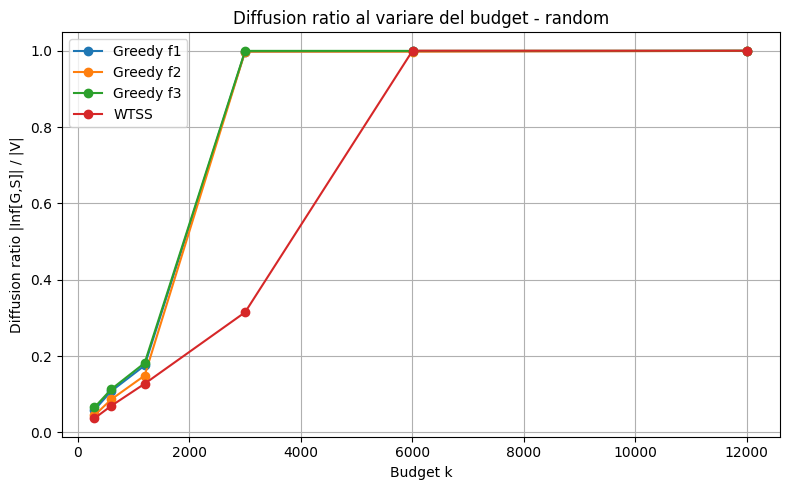

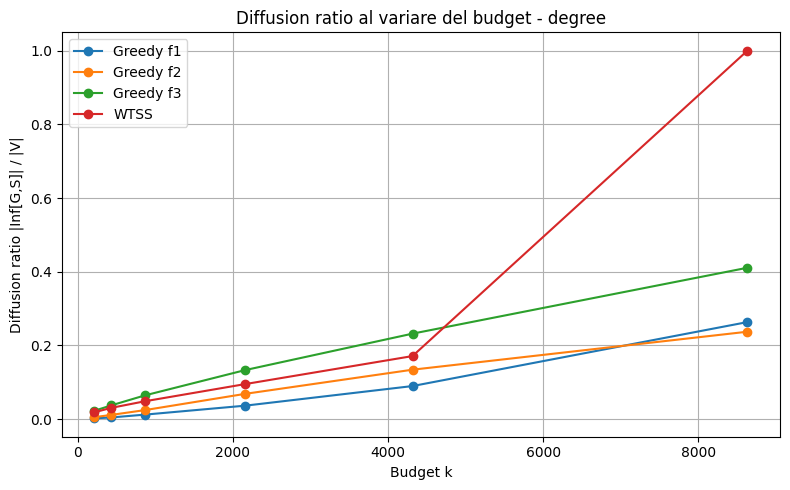

In [ ]:
for cost_name in cost_functions.keys():
    plot_influence_vs_budget(
        results_df=main_results_df,
        cost_function_name=cost_name,
        output_path=RESULTS_PLOTS_DIR / f"influence_vs_budget_{cost_name}.png"
    )

In [11]:
algorithms = get_algorithms()

stress_cost_name = "degree"
stress_algorithm_name = "Greedy f3"
stress_budget_percentage = 0.10

stress_costs = cost_functions[stress_cost_name]
stress_k = budgets_by_cost[stress_cost_name][stress_budget_percentage]

stress_algorithm = algorithms[stress_algorithm_name]

stress_seed_set = stress_algorithm(G, stress_k, stress_costs)
stress_activated_nodes = run_majority_cascade(G, stress_seed_set)

original_influence = len(stress_activated_nodes)
original_ratio = original_influence / G.number_of_nodes()

print(f"Algoritmo: {stress_algorithm_name}")
print(f"Funzione costo: {stress_cost_name}")
print(f"Budget k: {stress_k}")
print(f"|S|: {len(stress_seed_set)}")
print(f"c(S): {total_cost(stress_seed_set, stress_costs)}")
print(f"|Inf[G,S]|: {original_influence}")
print(f"Diffusion ratio: {original_ratio:.4f}")

Algoritmo: Greedy f3
Funzione costo: degree
Budget k: 4316
|S|: 826
c(S): 4311
|Inf[G,S]|: 2524
Diffusion ratio: 0.2321


In [12]:
edge_removal_percentages = [0.01, 0.05, 0.10, 0.20]

edge_results = run_edge_removal_experiment(
    G=G,
    seed_set=stress_seed_set,
    original_influence=original_influence,
    removal_percentages=edge_removal_percentages,
    seed=RANDOM_SEED,
)

edge_results_df = pd.DataFrame(edge_results)
edge_results_df

,removal_type,removal_percentage,removed_edges,original_influence,modified_influence,original_ratio,modified_ratio,absolute_loss,percentage_loss
0,edges,0.01,399,2524,2546,0.232071,0.234093,-22,-0.871632
1,edges,0.05,1999,2524,2621,0.232071,0.240989,-97,-3.843106
2,edges,0.10,3999,2524,2711,0.232071,0.249264,-187,-7.408875
3,edges,0.20,7998,2524,2945,0.232071,0.270780,-421,-16.679873


In [13]:
edge_results_df.to_csv(RESULTS_DATA_DIR / "edge_removal_results.csv", index=False)

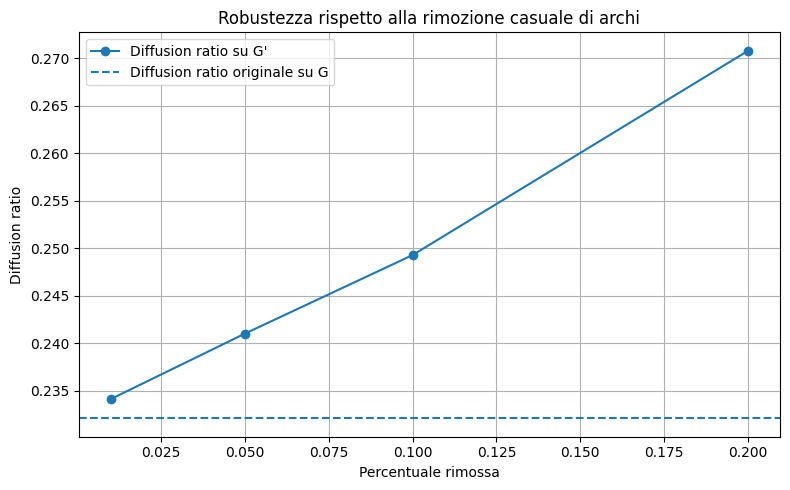

In [14]:
plot_removal_stress_test(
    results_df=edge_results_df,
    output_path=RESULTS_PLOTS_DIR / "edge_removal_stress_test.png",
    title="Robustezza rispetto alla rimozione casuale di archi"
)

In [15]:
node_removal_percentages = [0.01, 0.05, 0.10, 0.20]

node_results = run_node_removal_experiment(
    G=G,
    seed_set=stress_seed_set,
    original_influence=original_influence,
    removal_percentages=node_removal_percentages,
    seed=RANDOM_SEED,
)

node_results_df = pd.DataFrame(node_results)
node_results_df

,removal_type,removal_percentage,removed_nodes,removed_seed_nodes,original_influence,modified_influence,original_ratio,modified_ratio,absolute_loss,percentage_loss
0,nodes,0.01,108,3,2524,2539,0.232071,0.235791,-15,-0.594295
1,nodes,0.05,543,40,2524,2500,0.232071,0.241943,24,0.950872
2,nodes,0.10,1087,91,2524,2403,0.232071,0.245480,121,4.793978
3,nodes,0.20,2175,181,2524,2314,0.232071,0.265946,210,8.320127


In [16]:
node_results_df.to_csv(RESULTS_DATA_DIR / "node_removal_results.csv", index=False)

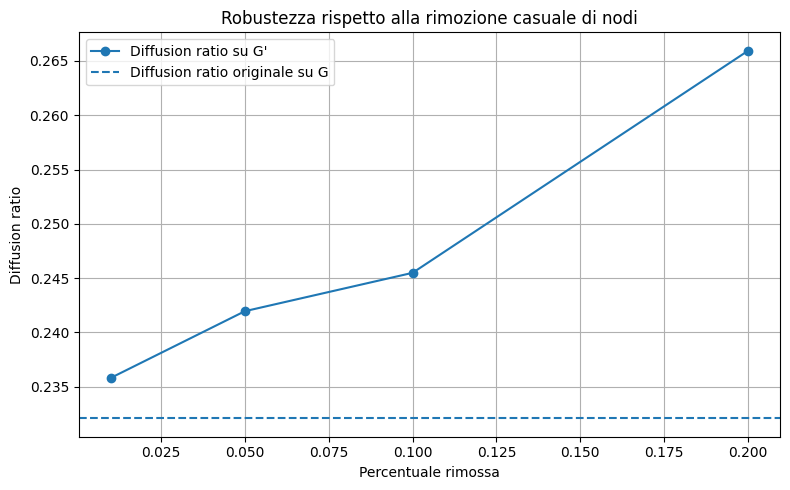

In [17]:
plot_removal_stress_test(
    results_df=node_results_df,
    output_path=RESULTS_PLOTS_DIR / "node_removal_stress_test.png",
    title="Robustezza rispetto alla rimozione casuale di nodi"
)